Mounted at /content/drive
Found 1133 images belonging to 2 classes.
Found 282 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 414s 11s/step - accuracy: 0.7190 - loss: 0.6116 - val_accuracy: 0.9255 - val_loss: 0.2683
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 283s 8s/step - accuracy: 0.9193 - loss: 0.2484 - val_accuracy: 0.9610 - val_loss: 0.1558
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 257s 7s/step - accuracy: 0.9696 - loss: 0.1411 - val_accuracy: 0.9645 - val_loss: 0.1101
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 251s 7s/step - accuracy: 0.9803 - loss: 0.0944 - val_accuracy: 0.9752 - val_loss: 0.0866
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 248s 7s/step - accuracy: 0.9796 - loss: 0.0766 - val_accuracy: 0.9752 - val_loss: 0.0738
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 287s 8s/step - accuracy: 0.9944 - loss: 0.0566 - val_accuracy: 0.9787 - val_loss: 0.0656
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 249s 7s/step - accuracy: 0.9881 - loss: 0.0541 - val_accuracy: 0.9787 - val_loss: 0.0560
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 248s 7s/step - accuracy: 0.9939 - loss: 0.0440 - val_accuracy: 0.9787 - 

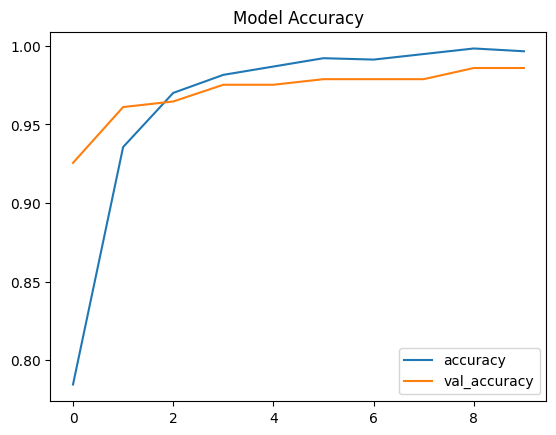

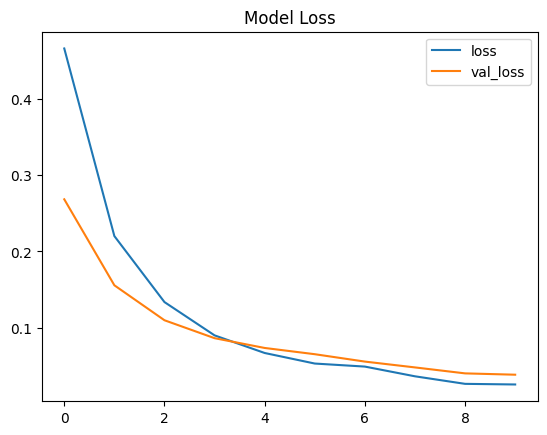

In [ ]:
# Import Google Drive access library from Google Colab
# This allows the notebook to access files stored in your Google Drive
from google.colab import drive

# Mount (connect) Google Drive to the Colab environment
# After running this, you can read and write files from your Drive
drive.mount('/content/drive')


# Import operating system utilities
# Used for working with file paths and directories
import os

# Import NumPy library for numerical calculations
# Helps handle arrays and mathematical operations
import numpy as np

# Import Matplotlib library for plotting graphs
# Used to visualize training results like accuracy and loss
import matplotlib.pyplot as plt

# Import TensorFlow library
# TensorFlow is the main machine learning framework used to build and train the model
import tensorflow as tf

# Import ImageDataGenerator
# This helps load images from folders and prepare them for model training
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Import ResNet50 model
# ResNet50 is a powerful pre-trained image recognition model
# It already knows many image patterns from training on millions of images
from tensorflow.keras.applications import ResNet50

# Import preprocessing function specifically designed for ResNet50
# It converts images into a format that the ResNet50 model understands
from tensorflow.keras.applications.resnet50 import preprocess_input

# Import Model class
# Used to create the final neural network architecture
from tensorflow.keras.models import Model

# Import neural network layers
# These layers help process image features and make predictions
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Import Adam optimizer
# This controls how the model learns during training
from tensorflow.keras.optimizers import Adam


# -----------------------------
# Dataset Paths
# -----------------------------

# Define the main dataset folder path in Google Drive
# This folder contains all training and validation images
base_dir = '/content/drive/MyDrive/ML_WSSV/WSSV/dataset/Augmented_data'

# Define path to training images
# These images will be used for teaching the model
train_dir = os.path.join(base_dir, 'train')

# Define path to validation images
# These images are used to test how well the model learned
val_dir = os.path.join(base_dir, 'validation_data')


# -----------------------------
# Image Data Generators
# -----------------------------

# Create a training data generator
# It loads images from folders and applies ResNet50 preprocessing
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Create a validation data generator
# It also preprocesses images for validation testing
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)


# Load training images from directory
# - target_size: resize images to 224x224 pixels (required for ResNet50)
# - batch_size: number of images processed at once
# - class_mode: binary because we have 2 classes (Healthy or WSSV)
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)


# Load validation images from directory
# These images are used to check model performance during training
val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)


# -----------------------------
# Build the Machine Learning Model
# -----------------------------

# Load ResNet50 model with pre-trained weights from ImageNet dataset
# include_top=False means we remove the final classification layers
# because we will add our own custom layers
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


# Freeze all layers of the base model
# This means the model will keep its existing knowledge
# and will not modify those layers during training
for layer in base_model.layers:
    layer.trainable = False


# Get the output feature maps from the base model
x = base_model.output

# Convert feature maps into a single vector
# This helps prepare the data for classification layers
x = GlobalAveragePooling2D()(x)

# Add a dense layer with 128 neurons
# This layer helps the model learn shrimp disease patterns
x = Dense(128, activation='relu')(x)

# Add dropout layer to reduce overfitting
# It randomly disables some neurons during training
x = Dropout(0.3)(x)

# Final output layer
# Since this is binary classification (Healthy vs WSSV)
# we use 1 neuron with sigmoid activation
predictions = Dense(1, activation='sigmoid')(x)


# Create the final model by combining base model and new layers
model = Model(inputs=base_model.input, outputs=predictions)


# -----------------------------
# Compile the Model
# -----------------------------

# Configure how the model will learn
model.compile(
    optimizer=Adam(learning_rate=0.0001),  # Learning speed of the model
    loss='binary_crossentropy',           # Loss function for binary classification
    metrics=['accuracy']                  # Measure model performance using accuracy
)


# -----------------------------
# Train the Model
# -----------------------------

# Train the model using training images
# epochs=10 means the model will see the entire dataset 10 times
# validation_data checks performance on unseen validation images
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)


# -----------------------------
# Save the Trained Model
# -----------------------------

# Save the trained model to Google Drive
# This model can later be used for prediction (inference)
model.save('/content/drive/MyDrive/ML_WSSV/WSSV/Trained_Model/resnet50_model.keras')


# -----------------------------
# Plot Training Results
# -----------------------------

# Import pandas for easier data handling
import pandas as pd

# Plot training accuracy vs validation accuracy
# This helps visualize how well the model is learning
pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot()

# Add title to the graph
plt.title('Model Accuracy')

# Display the graph
plt.show()


# Plot training loss vs validation loss
# Loss shows how far the model predictions are from the correct answer
pd.DataFrame(history.history)[['loss', 'val_loss']].plot()

# Add title to the graph
plt.title('Model Loss')

# Display the graph
plt.show()